In [45]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy import stats
from scipy import stats as sp_stats
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import NMF as SklearnNMF
RATING_MIN = 1.0
RATING_MAX = 10.0
TEST_PATH = 'test.csv'

# Load data and general stats

In [ ]:
file = "train.csv"
df = pd.read_csv(file, header=0)
df_test = pd.read_csv("test.csv", header=0)
df.head()

,user,item,rating
0,1,25715,7.0
1,1,25716,10.0
2,5,25851,9.0
3,6,25923,5.0
4,7,25924,6.0


In [70]:
df["rating"].min(), df["user"].unique().shape[0], df.shape

(1.0, 73456, (390351, 3))

In [48]:
y = df["rating"]
x = df.drop(columns="rating")

In [72]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=42, stratify=df.rating)

In [50]:
x_train.shape, x_val.shape

((351315, 2), (39036, 2))

# EDA

In [51]:
# ── Stats ──────────────────────────────────────────────────────────────────
n_users   = df['user'].nunique()
n_items   = df['item'].nunique()
n_ratings = len(df)
sparsity  = 1 - n_ratings / (n_users * n_items)
mu_global = df['rating'].mean()

ratings_per_user = df.groupby('user').size()
ratings_per_item = df.groupby('item').size()
cold_items = (ratings_per_item < 5).sum()
cold_users = (ratings_per_user < 5).sum()

stats = pd.DataFrame({
    'Métrica': ['Usuarios', 'Items', 'Ratings', 'Sparsidad',
                'Rating medio', 'Desv. típica',
                'Mediana ratings/usuario', 'Items cold-start (<5)',
                'Usuarios cold-start (<5)'],
    'Valor':   [f'{n_users:,}', f'{n_items:,}', f'{n_ratings:,}',
                f'{sparsity*100:.2f}%', f'{mu_global:.3f}',
                f'{df["rating"].std():.3f}',
                f'{ratings_per_user.median():.0f}',
                f'{cold_items} ({cold_items/n_items*100:.1f}%)',
                f'{cold_users} ({cold_users/n_users*100:.1f}%)']
})
display(stats.set_index('Métrica'))

,Valor
Métrica,
Usuarios,"73,456"
Items,"171,171"
Ratings,"390,351"
Sparsidad,100.00%
Rating medio,7.605
Desv. típica,1.843
Mediana ratings/usuario,1
Items cold-start (<5),158169 (92.4%)
Usuarios cold-start (<5),60298 (82.1%)


In [54]:
from scipy.sparse import csr_matrix

# ── Encoders usuario/item ─────────────────────────────────────────────────
user2idx = {u: i for i, u in enumerate(sorted(df['user'].unique()))}
item2idx = {it: i for i, it in enumerate(sorted(df['item'].unique()))}

df = df.copy()
df['user'] = df['user'].map(user2idx)
df['item'] = df['item'].map(item2idx)

N_USERS = len(user2idx)
N_ITEMS = len(item2idx)

# ── Split train / val (80/20) ─────────────────────────────────────────────
np.random.seed(24)
idx_all = np.random.permutation(len(df))
n_val   = int(len(df) * 0.20)

val_df   = df.iloc[idx_all[:n_val]].reset_index(drop=True)
train_df = df.iloc[idx_all[n_val:]].reset_index(drop=True)
test_df  = val_df

print(f'Train : {len(train_df):,}  ({len(train_df)/len(df)*100:.1f}%)')
print(f'Val   : {len(val_df):,}  ({len(val_df)/len(df)*100:.1f}%)')
print(f'N_USERS={N_USERS} | N_ITEMS={N_ITEMS}')

# ── Matriz SPARSE para NMF ────────────────────────────────────────────────
R_sparse = csr_matrix(
    (train_df['rating'].values, (train_df['user'].values, train_df['item'].values)),
    shape=(N_USERS, N_ITEMS)
)
print(f'\nR_sparse: {R_sparse.shape} | nnz={R_sparse.nnz:,} | '
      f'sparsidad: {(1 - R_sparse.nnz/(N_USERS*N_ITEMS))*100:.1f}%')

R_train = None  # matriz densa no viable — 93 GB

# ── Carga del test de la competición ──────────────────────────────────────
df_test_comp = pd.read_csv(TEST_PATH)
df_test_comp['user'] = df_test_comp['user'].map(user2idx).fillna(-1).astype(int)
df_test_comp['item'] = df_test_comp['item'].map(item2idx).fillna(-1).astype(int)

print(f'\nTest competición: {len(df_test_comp):,} pares a predecir')
cold_u = (df_test_comp['user'] == -1).sum()
cold_i = (df_test_comp['item'] == -1).sum()
if cold_u or cold_i:
    print(f'  ⚠ Cold-start: {cold_u} usuarios y {cold_i} items no vistos en train')

Train : 312,281  (80.0%)
Val   : 78,070  (20.0%)
N_USERS=73456 | N_ITEMS=171171

R_sparse: (73456, 171171) | nnz=312,281 | sparsidad: 100.0%

Test competición: 43,320 pares a predecir
  ⚠ Cold-start: 4765 usuarios y 16157 items no vistos en train


In [55]:
def mae(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))


def evaluar(nombre, predict_fn, eval_df, verbose=True):
    y_true, y_pred = [], []
    for row in eval_df.itertuples():
        pred = float(np.clip(predict_fn(row.user, row.item), RATING_MIN, RATING_MAX))
        y_true.append(row.rating)
        y_pred.append(pred)
    score = mae(y_true, y_pred)
    if verbose:
        print(f'  {nombre:<8}  MAE = {score:.4f}')
    return {'modelo': nombre, 'MAE': score}


resultados = []
print(f'Métrica MAE lista. Clamp: [{RATING_MIN}, {RATING_MAX}]')

# ── Baselines ──────────────────────────────────────────────────────────────
mu_global        = df['rating'].mean()
item_means       = df.groupby('item')['rating'].mean()
user_means_train = df.groupby('user')['rating'].mean()

def predict_mean(user, item):
    return mu_global

def predict_item_mean(user, item):
    return item_means.get(item, mu_global)

def predict_user_mean(user, item):
    return user_means_train.get(user, mu_global)

res_mean      = evaluar('MediaGlobal', predict_mean,      test_df)
res_item_mean = evaluar('MediaItem',   predict_item_mean, test_df)
res_user_mean = evaluar('MediaUser',   predict_user_mean, test_df)

resultados.extend([res_mean, res_item_mean, res_user_mean])

Métrica MAE lista. Clamp: [1.0, 10.0]
  MediaGlobal  MAE = 1.4921
  MediaItem  MAE = 0.8231
  MediaUser  MAE = 1.0059


Rango de ratings: [1.0, 10.0]
Dimensiones train: (390351, 3)
Rango ratings: [1.0, 10.0]


,Valor
Métrica,
Usuarios,"73,456"
Items,"171,171"
Ratings,"390,351"
Sparsidad,100.00%
Rating medio,7.605
Desv. típica,1.843
Mediana ratings/usuario,1
Items cold-start (<5),158169 (92.4%)


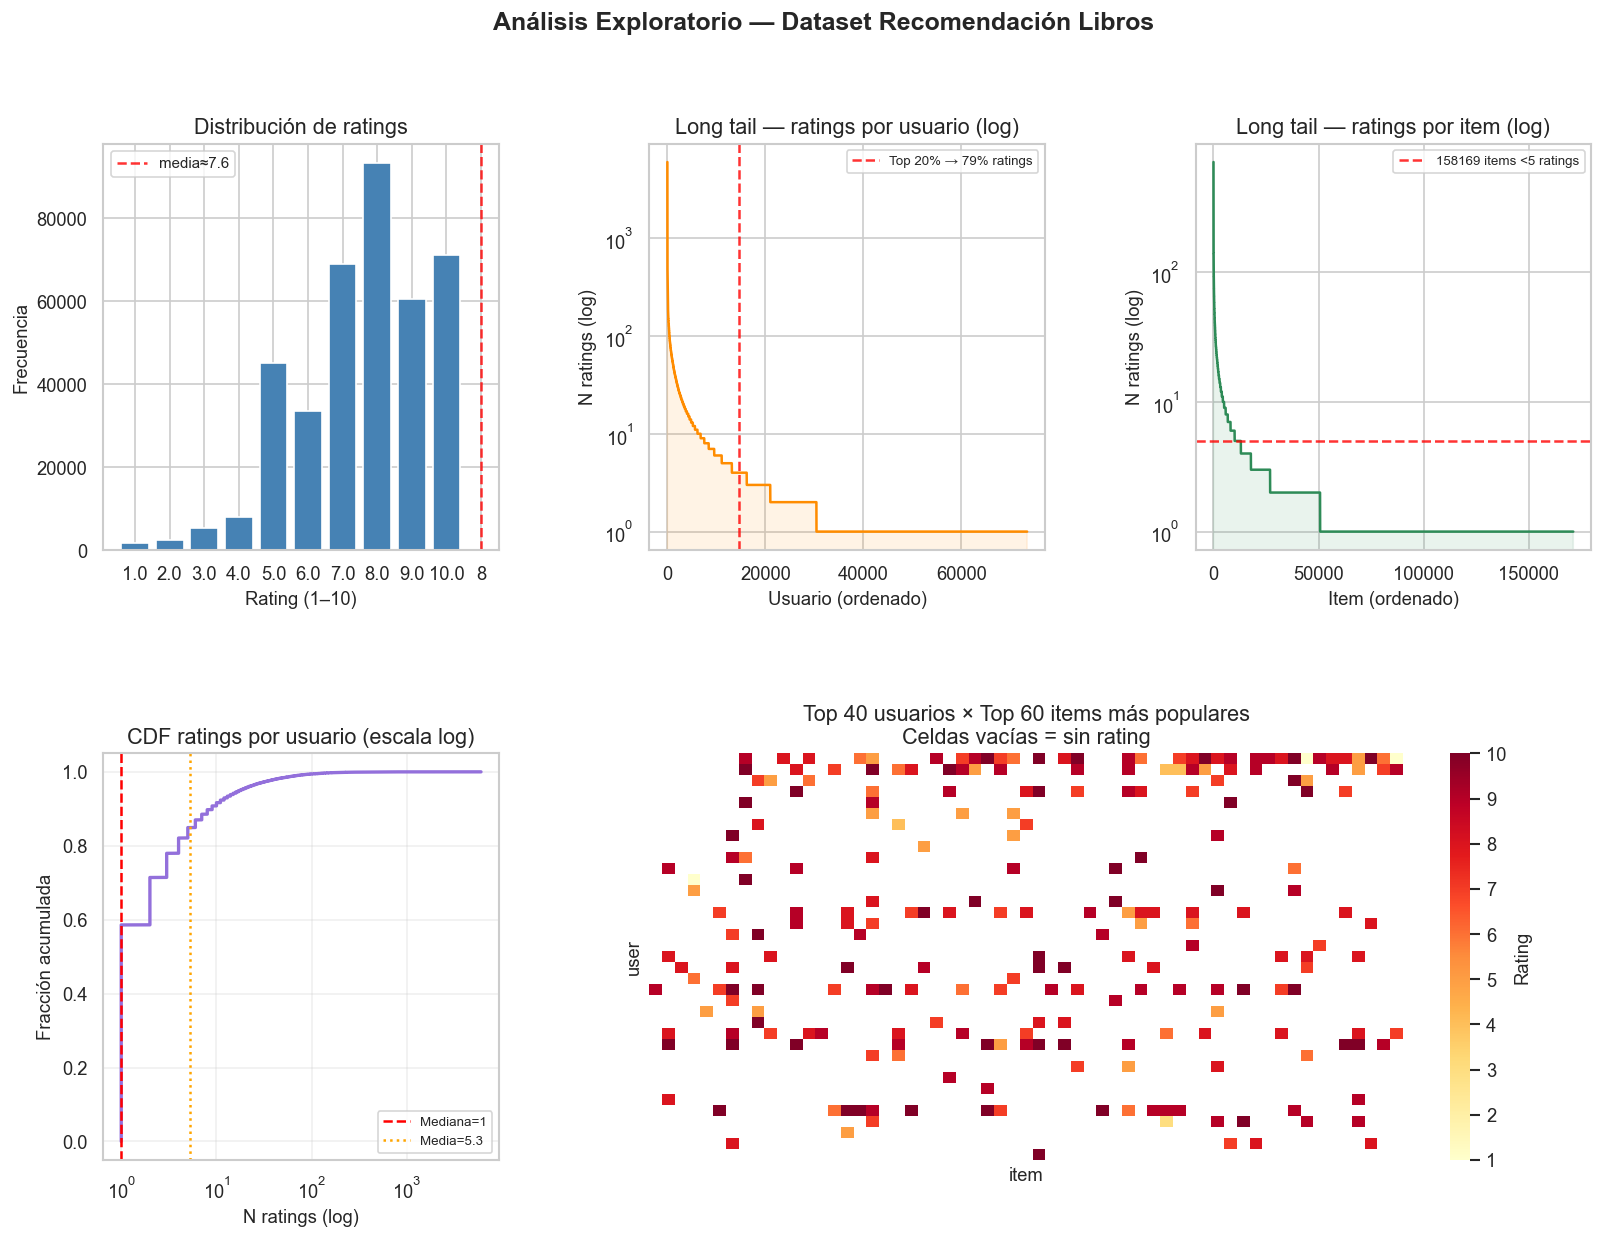


Conclusiones EDA:
  Ratings 1–10 (media=7.60): sesgo hacia puntuaciones altas.
  Sparsidad 100.0%: la mayoría de pares usuario-item no tienen rating.
  Mediana 1 rating/usuario: long tail extrema, KNN sufre.
  158169 items cold-start (92.4%): fallback a media global necesario.
No hay ratings duplicados — no se puede estimar directamente
Desviación típica media intra-usuario: 1.3532
Ceiling teórico aproximado: ~0.9473


In [38]:
SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

N_FACTORS = 20
N_EPOCHS  = 50
LR        = 0.005
REG       = 0.02
K_KNN     = 20

print(f'Rango de ratings: [{RATING_MIN}, {RATING_MAX}]')
df_test = pd.read_csv(TEST_PATH)
df_test['user'] = df_test['user'].map(user2idx).fillna(-1).astype(int)
df_test['item'] = df_test['item'].map(item2idx).fillna(-1).astype(int)

df_ratings = df.copy()
df_ratings = df_ratings[['user', 'item', 'rating']]

print(f'Dimensiones train: {df_ratings.shape}')
print(f'Rango ratings: [{df_ratings["rating"].min()}, {df_ratings["rating"].max()}]')
df_ratings.head()

n_users   = df_ratings['user'].nunique()
n_items   = df_ratings['item'].nunique()
ratings_per_user = df_ratings.groupby('user').size()
ratings_per_item = df_ratings.groupby('item').size()

n_ratings = len(df_ratings)
sparsity  = 1 - n_ratings / (n_users * n_items)
mu_global = df_ratings['rating'].mean()

cold_items = (ratings_per_item < 5).sum()
cold_users = (ratings_per_user < 5).sum()

stats = pd.DataFrame({
    'Métrica': ['Usuarios', 'Items', 'Ratings', 'Sparsidad',
                'Rating medio', 'Desv. típica',
                'Mediana ratings/usuario', 'Items cold-start (<5)'],
    'Valor':   [f'{n_users:,}', f'{n_items:,}', f'{n_ratings:,}',
                f'{sparsity*100:.2f}%', f'{mu_global:.3f}',
                f'{df_ratings["rating"].std():.3f}',
                f'{ratings_per_user.median():.0f}',
                f'{cold_items} ({cold_items/n_items*100:.1f}%)']
})
display(stats.set_index('Métrica'))


fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.38)

# Distribución de ratings
ax1 = fig.add_subplot(gs[0, 0])
counts = df_ratings['rating'].value_counts().sort_index()
bars = ax1.bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor='white')
ax1.axvline(str(round(mu_global)), color='red', linestyle='--', alpha=0.8,
            label=f'media≈{mu_global:.1f}')
ax1.set_title('Distribución de ratings')
ax1.set_xlabel('Rating (1–10)'); ax1.set_ylabel('Frecuencia')
ax1.legend(fontsize=9)

# Long tail usuarios, escala log para que se vea la cola
ax2 = fig.add_subplot(gs[0, 1])
su  = ratings_per_user.sort_values(ascending=False).values
ax2.semilogy(su, color='darkorange', linewidth=1.5)
ax2.fill_between(range(len(su)), su, alpha=0.1, color='darkorange')
p20   = int(len(su) * 0.2)
pct_u = su[:p20].sum() / n_ratings * 100
ax2.axvline(p20, color='red', linestyle='--', alpha=0.8,
            label=f'Top 20% → {pct_u:.0f}% ratings')
ax2.set_title('Long tail — ratings por usuario (log)')
ax2.set_xlabel('Usuario (ordenado)'); ax2.set_ylabel('N ratings (log)')
ax2.legend(fontsize=8)

# Long tail items, escala log
ax3 = fig.add_subplot(gs[0, 2])
si  = ratings_per_item.sort_values(ascending=False).values
ax3.semilogy(si, color='seagreen', linewidth=1.5)
ax3.fill_between(range(len(si)), si, alpha=0.1, color='seagreen')
ax3.axhline(5, color='red', linestyle='--', alpha=0.8,
            label=f'{cold_items} items <5 ratings')
ax3.set_title('Long tail — ratings por item (log)')
ax3.set_xlabel('Item (ordenado)'); ax3.set_ylabel('N ratings (log)')
ax3.legend(fontsize=8)

# Distribución acumulada de ratings por usuario (CDF)
ax4 = fig.add_subplot(gs[1, 0])
sorted_u = np.sort(ratings_per_user.values)
cdf = np.arange(1, len(sorted_u)+1) / len(sorted_u)
ax4.plot(sorted_u, cdf, color='mediumpurple', linewidth=2)
ax4.axvline(ratings_per_user.median(), color='red', linestyle='--',
            label=f'Mediana={ratings_per_user.median():.0f}')
ax4.axvline(ratings_per_user.mean(), color='orange', linestyle=':',
            label=f'Media={ratings_per_user.mean():.1f}')
ax4.set_xscale('log')
ax4.set_title('CDF ratings por usuario (escala log)')
ax4.set_xlabel('N ratings (log)'); ax4.set_ylabel('Fracción acumulada')
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

# Heatmap. usuarios con más ratings para que haya solapamiento visible
ax5 = fig.add_subplot(gs[1, 1:])
top_u  = ratings_per_user.nlargest(40).index
pop_i  = ratings_per_item.nlargest(60).index
pivot  = df_ratings[
    df_ratings['user'].isin(top_u) & df_ratings['item'].isin(pop_i)
].pivot_table(index='user', columns='item', values='rating')
sns.heatmap(pivot, ax=ax5, cmap='YlOrRd', vmin=RATING_MIN, vmax=RATING_MAX,
            cbar_kws={'label': 'Rating'}, xticklabels=False, yticklabels=False,
            linewidths=0)
ax5.set_title('Top 40 usuarios × Top 60 items más populares\nCeldas vacías = sin rating')

fig.suptitle('Análisis Exploratorio — Dataset Recomendación Libros', fontsize=15, fontweight='bold')
plt.savefig('eda.png', bbox_inches='tight'); plt.show()

print('\nConclusiones EDA:')
print(f'  Ratings 1–10 (media={mu_global:.2f}): sesgo hacia puntuaciones altas.')
print(f'  Sparsidad {sparsity*100:.1f}%: la mayoría de pares usuario-item no tienen rating.')
print(f'  Mediana {ratings_per_user.median():.0f} rating/usuario: long tail extrema, KNN sufre.')
print(f'  {cold_items} items cold-start ({cold_items/n_items*100:.1f}%): fallback a media global necesario.')

duplicados = df_ratings.groupby(['user', 'item']).size()
duplicados = duplicados[duplicados > 1]

if len(duplicados) > 0:
    pairs = df_ratings.groupby(['user', 'item'])['rating'].apply(list)
    pairs_multi = pairs[pairs.apply(len) > 1]
    errores = []
    for ratings_list in pairs_multi:
        media = np.mean(ratings_list)
        for r in ratings_list:
            errores.append(abs(r - media))
    print(f'Error de Bayes estimado: {np.mean(errores):.4f}')
else:
    print('No hay ratings duplicados — no se puede estimar directamente')
    std_intra = df_ratings.groupby('user')['rating'].std().dropna().mean()
    print(f'Desviación típica media intra-usuario: {std_intra:.4f}')
    print(f'Ceiling teórico aproximado: ~{std_intra * 0.7:.4f}')

# Functions for training

In [25]:
# Creamos la matriz de disperson con mapings de usuarios e ítems
def create_sparse_matrix(x_train, y_train):
    user_map = {u: i for i, u in enumerate(x_train['user'].unique())}
    item_map = {it: i for i, it in enumerate(x_train['item'].unique())}

    row = x_train['user'].map(user_map)
    col = x_train['item'].map(item_map)
    data = y_train.values

    sparse_matrix = csr_matrix(
        (data, (row, col)),
        shape=(len(user_map), len(item_map))
        ) 
    return sparse_matrix, user_map, item_map

# calculamos las estadísticas del dataset necesarias para gestionar los cold-starts y normalizar distancias
def compute_stats(sparse_matrix):
    csr = sparse_matrix.tocsr()
    csc = sparse_matrix.tocsc()

    user_sums   = np.array(csr.sum(axis=1)).flatten()
    user_counts = np.diff(csr.indptr)
    user_means  = np.where(user_counts > 0, user_sums / user_counts, np.nan)

    item_sums   = np.array(csc.sum(axis=0)).flatten()
    item_counts = np.diff(csc.indptr)
    item_means  = np.where(item_counts > 0, item_sums / item_counts, np.nan)

    global_mean = float(csr.data.mean()) if len(csr.data) > 0 else 0.0

    return user_means, item_means, global_mean


def get_user_distances_for_item(user_idx, item_idx, sparse_matrix, metrics, user_means):
    vec_a     = sparse_matrix[user_idx].toarray().flatten()
    nonzero_a = set(np.where(vec_a != 0)[0])
    mean_a    = user_means[user_idx]

    item_col          = sparse_matrix[:, item_idx].toarray().flatten()
    candidate_indices = np.where(
        (item_col != 0) & (np.arange(len(item_col)) != user_idx)
    )[0]

    if len(candidate_indices) == 0:
        return {m: np.array([]) for m in metrics}, np.array([]), np.array([])

    distances = {m: [] for m in metrics}
    ratings, valid_idx = [], []

    for j in candidate_indices:
        vec_b  = sparse_matrix[j].toarray().flatten()
        common = list(nonzero_a & set(np.where(vec_b != 0)[0]))
        if len(common) == 0:
            continue

        a, b   = vec_a[common], vec_b[common]
        mean_b = user_means[j]
        metric_results = {}

        if 'cosine' in metrics:
            norm = np.linalg.norm(a) * np.linalg.norm(b)
            metric_results['cosine'] = 1 - (np.dot(a, b) / norm) if norm > 0 else None

        if 'euclidean' in metrics:
            metric_results['euclidean'] = np.sqrt(np.sum((a - b) ** 2))

        if 'euclidean_bias' in metrics:
            if np.isnan(mean_a) or np.isnan(mean_b):
                metric_results['euclidean_bias'] = None
            else:
                metric_results['euclidean_bias'] = np.sqrt(
                    np.sum(((a - mean_a) - (b - mean_b)) ** 2)
                )

        if 'pearson' in metrics:
            if np.std(a) == 0 or np.std(b) == 0:
                metric_results['pearson'] = None
            else:
                metric_results['pearson'] = 1 - np.corrcoef(a, b)[0, 1]
        
        if 'manhattan' in metrics:
            metric_results['manhattan'] = np.sum(np.abs(a - b))

        if 'jaccard_weighted' in metrics:
            if np.isnan(mean_a) or np.isnan(mean_b):
                metric_results['jaccard_weighted'] = None
            else:
                a_n = a - mean_a
                b_n = b - mean_b
                numerator = np.sum(np.minimum(np.abs(a_n), np.abs(b_n)))
                denominator = np.sum(np.maximum(np.abs(a_n), np.abs(b_n)))

                if denominator == 0:
                    metric_results['jaccard_weighted'] = None
                else:
                    metric_results['jaccard_weighted'] = 1 - (numerator / denominator)

        if any(v is None for v in metric_results.values()):
            continue

        for m in metrics:
            distances[m].append(metric_results[m])
        ratings.append(item_col[j])
        valid_idx.append(j)

    return (
        {m: np.array(distances[m]) for m in metrics},
        np.array(ratings),
        np.array(valid_idx)
    )

def _expand_strategies(strats):
    """Expande 'range_1_10' en ['const_1', 'const_2', ..., 'const_10']."""
    expanded = []
    for s in strats:
        if s == 'range_1_10':
            expanded.extend([f'const_{v}' for v in range(1, 11)])
        else:
            expanded.append(s)
    return expanded


def evaluate_knn(x_val, y_val, sparse_matrix, user_map, item_map,
                 k_max=20, metrics=('cosine',), error_metric='rmse',
                 cold_start=None):
    if cold_start is None:
        cold_start = {
            'unknown_user' : ['item_mean', 'global_mean', 'range_1_10'],
            'unknown_item' : ['user_mean', 'global_mean', 'range_1_10'],
            'both_unknown' : ['global_mean', 'range_1_10'],
        }

    cold_start = {case: _expand_strategies(strats) for case, strats in cold_start.items()}

    metrics  = list(metrics)
    k_values = list(range(2, k_max + 1))

    user_means, item_means, global_mean = compute_stats(sparse_matrix)

    val_df = x_val.copy()
    val_df['y_true'] = y_val.values
    val_df.columns   = ['user', 'item', 'y_true']

    knn_errors = {m: {k: [] for k in k_values} for m in metrics}
    cs_errors  = {
        case: {strat: [] for strat in strats}
        for case, strats in cold_start.items()
    }

    def _cold_pred(strat, user_idx=None, item_idx=None):
        if strat == 'item_mean':
            v = item_means[item_idx] if item_idx is not None else np.nan
        elif strat == 'user_mean':
            v = user_means[user_idx] if user_idx is not None else np.nan
        elif strat == 'global_mean':
            v = global_mean
        elif strat.startswith('const_'):
            v = float(strat.split('_')[1])
        else:
            v = np.nan
        return global_mean if (isinstance(v, float) and np.isnan(v)) else v

    def _err(pred, true):
        return (pred - true) ** 2 if error_metric == 'rmse' else abs(pred - true)

    for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc="Evaluating"):
        user_id, item_id, y_true = row['user'], row['item'], row['y_true']

        user_known = user_id in user_map
        item_known = item_id in item_map

        if not user_known or not item_known:
            if not user_known and not item_known:
                case = 'both_unknown'
                for strat in cold_start.get(case, []):
                    cs_errors[case][strat].append(_err(_cold_pred(strat), y_true))

            elif not user_known:
                case     = 'unknown_user'
                item_idx = item_map[item_id]
                for strat in cold_start.get(case, []):
                    cs_errors[case][strat].append(
                        _err(_cold_pred(strat, item_idx=item_idx), y_true)
                    )
            else:
                case     = 'unknown_item'
                user_idx = user_map[user_id]
                for strat in cold_start.get(case, []):
                    cs_errors[case][strat].append(
                        _err(_cold_pred(strat, user_idx=user_idx), y_true)
                    )
            continue

        user_idx = user_map[user_id]
        item_idx = item_map[item_id]

        dist_by_metric, ratings, _ = get_user_distances_for_item(
            user_idx, item_idx, sparse_matrix, metrics, user_means
        )

        if len(ratings) == 0:
            continue

        for m in metrics:
            distances = dist_by_metric[m]
            if len(distances) == 0:
                continue
            sorted_idx = np.argsort(distances)
            for k in k_values:
                k_actual = min(k, len(sorted_idx))
                top_idx  = sorted_idx[:k_actual]
                top_d    = distances[top_idx]
                top_r    = ratings[top_idx]
                weights  = 1 / (top_d + 1e-8)
                pred     = np.dot(weights, top_r) / weights.sum()
                knn_errors[m][k].append(_err(pred, y_true))

    def _agg(lst):
        if not lst:
            return np.nan
        return np.sqrt(np.mean(lst)) if error_metric == 'rmse' else np.mean(lst)

    knn_results = {
        m: (k_values, [_agg(knn_errors[m][k]) for k in k_values])
        for m in metrics
    }
    cs_results = {
        case: {strat: _agg(errs) for strat, errs in strats.items()}
        for case, strats in cs_errors.items()
    }

    return {'knn': knn_results, 'cold_start': cs_results}

def predict(x_test, sparse_matrix, user_map, item_map,
            user_means, item_means, global_mean,
            metric='jaccard_weighted', k=5,
            cold_start_unknown_user='global_mean',
            cold_start_unknown_item='user_mean',
            cold_start_both='const_7'):

    def _cold_pred(strat, user_idx=None, item_idx=None):
        if strat == 'item_mean':
            v = item_means[item_idx] if item_idx is not None else np.nan
        elif strat == 'user_mean':
            v = user_means[user_idx] if user_idx is not None else np.nan
        elif strat == 'global_mean':
            v = global_mean
        elif strat.startswith('const_'):
            v = float(strat.split('_')[1])
        else:
            v = np.nan
        return global_mean if (isinstance(v, float) and np.isnan(v)) else v

    ids   = []
    preds = []

    for _, row in tqdm(x_test.iterrows(), total=len(x_test), desc="Predicting"):
        row_id  = row.iloc[0] 
        user_id = row.iloc[1]
        item_id = row.iloc[2]

        user_known = user_id in user_map
        item_known = item_id in item_map

        ids.append(row_id)

        if not user_known and not item_known:
            preds.append(_cold_pred(cold_start_both))
            continue

        if not user_known:
            item_idx = item_map[item_id]
            preds.append(_cold_pred(cold_start_unknown_user, item_idx=item_idx))
            continue

        if not item_known:
            user_idx = user_map[user_id]
            preds.append(_cold_pred(cold_start_unknown_item, user_idx=user_idx))
            continue

        user_idx = user_map[user_id]
        item_idx = item_map[item_id]

        distances, ratings, _ = get_user_distances_for_item(
            user_idx, item_idx, sparse_matrix, [metric], user_means
        )
        distances = distances[metric]

        # Fallback si no hay vecinos con ítems en común
        if len(distances) == 0:
            preds.append(_cold_pred(cold_start_unknown_item, user_idx=user_idx))
            continue

        sorted_idx = np.argsort(distances)
        k_actual   = min(k, len(sorted_idx))
        top_idx    = sorted_idx[:k_actual]
        top_d      = distances[top_idx]
        top_r      = ratings[top_idx]
        weights    = 1 / (top_d + 1e-8)
        pred       = np.dot(weights, top_r) / weights.sum()

        preds.append(pred)

    return pd.DataFrame({'id': ids, 'rating': preds})


# aquí sacamos estdísticas del dataset y formas de gestionar los cold-starts
def analyze_coldstart(x_train, y_train, x_val, y_val, user_map, item_map):

    all_ratings    = y_train.values
    global_mean    = float(np.mean(all_ratings))
    global_median  = float(np.median(all_ratings))
    global_mode    = float(sp_stats.mode(all_ratings, keepdims=True).mode[0])  # ← sp_stats

    train_df = x_train.copy()
    train_df.columns = ['user', 'item']
    train_df['rating'] = y_train.values

    user_stats = train_df.groupby('user')['rating'].agg(
        mean='mean', median='median',
        mode=lambda x: sp_stats.mode(x, keepdims=True).mode[0]  # ← sp_stats
    )
    item_stats = train_df.groupby('item')['rating'].agg(
        mean='mean', median='median',
        mode=lambda x: sp_stats.mode(x, keepdims=True).mode[0]  # ← sp_stats
    )

    val_df = x_val.copy()
    val_df.columns = ['user', 'item']
    val_df['rating'] = y_val.values
    val_df['u_known'] = val_df['user'].isin(user_map)
    val_df['i_known'] = val_df['item'].isin(item_map)

    cases = {
        'unknown_user' : val_df[ val_df['u_known'] & ~val_df['i_known']],
        'unknown_item' : val_df[~val_df['u_known'] &  val_df['i_known']],
        'both_unknown' : val_df[~val_df['u_known'] & ~val_df['i_known']],
    }
    cases = {
        'unknown_user' : val_df[~val_df['u_known'] &  val_df['i_known']],
        'unknown_item' : val_df[ val_df['u_known'] & ~val_df['i_known']],
        'both_unknown' : val_df[~val_df['u_known'] & ~val_df['i_known']],
    }

    print(f"Casos cold-start en validación:")
    for case, df in cases.items():
        print(f"  {case:<15}: {len(df):>5} ({len(df)/len(val_df)*100:.1f}%)")

    best_strategies = {}

    for case, df in cases.items():
        if len(df) == 0:
            print(f"\n[{case}] Sin casos en validación, skipping.")
            continue

        y_true = df['rating'].values

        strategies = {}

        # Constantes 1-10
        for v in range(1, 11):
            strategies[f'const_{v}'] = np.full(len(df), float(v))

        # Globales
        strategies['global_mean']   = np.full(len(df), global_mean)
        strategies['global_median'] = np.full(len(df), global_median)
        strategies['global_mode']   = np.full(len(df), global_mode)

        # Basadas en ítem (cuando el ítem es conocido)
        if case == 'unknown_user':
            item_mean_preds, item_med_preds, item_mode_preds = [], [], []
            for item_id in df['item']:
                if item_id in item_stats.index:
                    item_mean_preds.append(item_stats.loc[item_id, 'mean'])
                    item_med_preds.append(item_stats.loc[item_id, 'median'])
                    item_mode_preds.append(item_stats.loc[item_id, 'mode'])
                else:
                    item_mean_preds.append(global_mean)
                    item_med_preds.append(global_median)
                    item_mode_preds.append(global_mode)
            strategies['item_mean']   = np.array(item_mean_preds)
            strategies['item_median'] = np.array(item_med_preds)
            strategies['item_mode']   = np.array(item_mode_preds)

        # Basadas en usuario (cuando el usuario es conocido)
        if case == 'unknown_item':
            user_mean_preds, user_med_preds, user_mode_preds = [], [], []
            for user_id in df['user']:
                if user_id in user_stats.index:
                    user_mean_preds.append(user_stats.loc[user_id, 'mean'])
                    user_med_preds.append(user_stats.loc[user_id, 'median'])
                    user_mode_preds.append(user_stats.loc[user_id, 'mode'])
                else:
                    user_mean_preds.append(global_mean)
                    user_med_preds.append(global_median)
                    user_mode_preds.append(global_mode)
            strategies['user_mean']   = np.array(user_mean_preds)
            strategies['user_median'] = np.array(user_med_preds)
            strategies['user_mode']   = np.array(user_mode_preds)

        results = {}
        for name, preds in strategies.items():
            results[name] = float(np.mean(np.abs(preds - y_true)))

        results_df = pd.DataFrame({'strategy': list(results.keys()),
                                   'mae': list(results.values())})
        results_df = results_df.sort_values('mae').reset_index(drop=True)
        best_strat = results_df.iloc[0]['strategy']
        best_strategies[case] = {
            'strategy' : best_strat,
            'mae'      : results_df.iloc[0]['mae'],
            'all'      : results_df
        }

        print(f"\n── {case} (n={len(df)}) ──────────────────────────────")
        print(results_df.to_string(index=False))
        print(f"  → Mejor estrategia: {best_strat} (MAE={results_df.iloc[0]['mae']:.4f})")

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

        colors = ['#70ad47' if s == best_strat else
                  '#5b9bd5' if s.startswith('const_') else
                  '#ed7d31' if 'mean' in s or 'median' in s or 'mode' in s else
                  '#a9a9a9'
                  for s in results_df['strategy']]

        bars = ax1.bar(range(len(results_df)), results_df['mae'],
                       color=colors, edgecolor='white')
        ax1.set_xticks(range(len(results_df)))
        ax1.set_xticklabels(results_df['strategy'], rotation=45, ha='right', fontsize=8)
        ax1.set_ylabel('MAE')
        ax1.set_title(f'[{case}] MAE por estrategia')
        ax1.grid(True, axis='y', alpha=0.4)

        y_off = (results_df['mae'].max() - results_df['mae'].min()) * 0.01 + 0.001
        for bar, val in zip(bars, results_df['mae']):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_off,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=7)

        from matplotlib.patches import Patch
        ax1.legend(handles=[
            Patch(color='#70ad47', label='Best'),
            Patch(color='#5b9bd5', label='Constant (1-10)'),
            Patch(color='#ed7d31', label='Stat-based'),
        ], fontsize=8)

        ax2.hist(y_true, bins=np.arange(0.5, 11.5, 1), color='steelblue',
                 edgecolor='white', alpha=0.8)
        ax2.axvline(global_mean,   color='red',    linestyle='--', label=f'global mean={global_mean:.2f}')
        ax2.axvline(global_median, color='orange', linestyle='--', label=f'global median={global_median:.2f}')
        ax2.set_xlabel('Rating')
        ax2.set_ylabel('Count')
        ax2.set_title(f'[{case}] Distribución de ratings reales')
        ax2.legend(fontsize=8)
        ax2.grid(True, alpha=0.4)

        fig.suptitle(f'Cold-start analysis — {case}', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return best_strategies, user_stats, item_stats, global_mean



def plot_knn_error(results, error_metric='mae'):
    """
    Figura única: error KNN vs k (una línea por métrica).
    La parte de cold-start se gestiona aparte con analyze_coldstart().
    """
    knn_results = results['knn']
    knn_colors  = ['steelblue', 'darkorange', 'seagreen', 'crimson',
                   'mediumpurple', 'saddlebrown']
    best_ks = {}

    fig, ax = plt.subplots(figsize=(13, 6))

    for i, (metric, (k_values, errors)) in enumerate(knn_results.items()):
        color  = knn_colors[i % len(knn_colors)]
        best_k = k_values[int(np.nanargmin(errors))]
        best_ks[metric] = best_k
        ax.plot(
            k_values, errors,
            marker='o', linewidth=2, color=color,
            label=f'{metric}  (best k={best_k}, {error_metric.upper()}={np.nanmin(errors):.4f})'
        )
        ax.axvline(best_k, color=color, linestyle='--', alpha=0.35)

    ax.set_xlabel('k', fontsize=12)
    ax.set_ylabel(error_metric.upper(), fontsize=12)
    ax.set_title(f'KNN validation error vs k — {error_metric.upper()}',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.4)
    fig.tight_layout()
    plt.show()

    return best_ks

# Statistics and KNN model

Casos cold-start en validación:
  unknown_user   :  3264 (8.4%)
  unknown_item   : 11212 (28.7%)
  both_unknown   :  1317 (3.4%)

── unknown_user (n=3264) ──────────────────────────────
     strategy      mae
      const_8 1.369792
global_median 1.369792
  global_mode 1.369792
  global_mean 1.428172
  item_median 1.458333
    item_mean 1.459555
      const_7 1.517463
    item_mode 1.649510
      const_9 1.754596
      const_6 2.043199
     const_10 2.439645
      const_5 2.750306
      const_4 3.648591
      const_3 4.594056
      const_2 5.570772
      const_1 6.560355
  → Mejor estrategia: const_8 (MAE=1.3698)


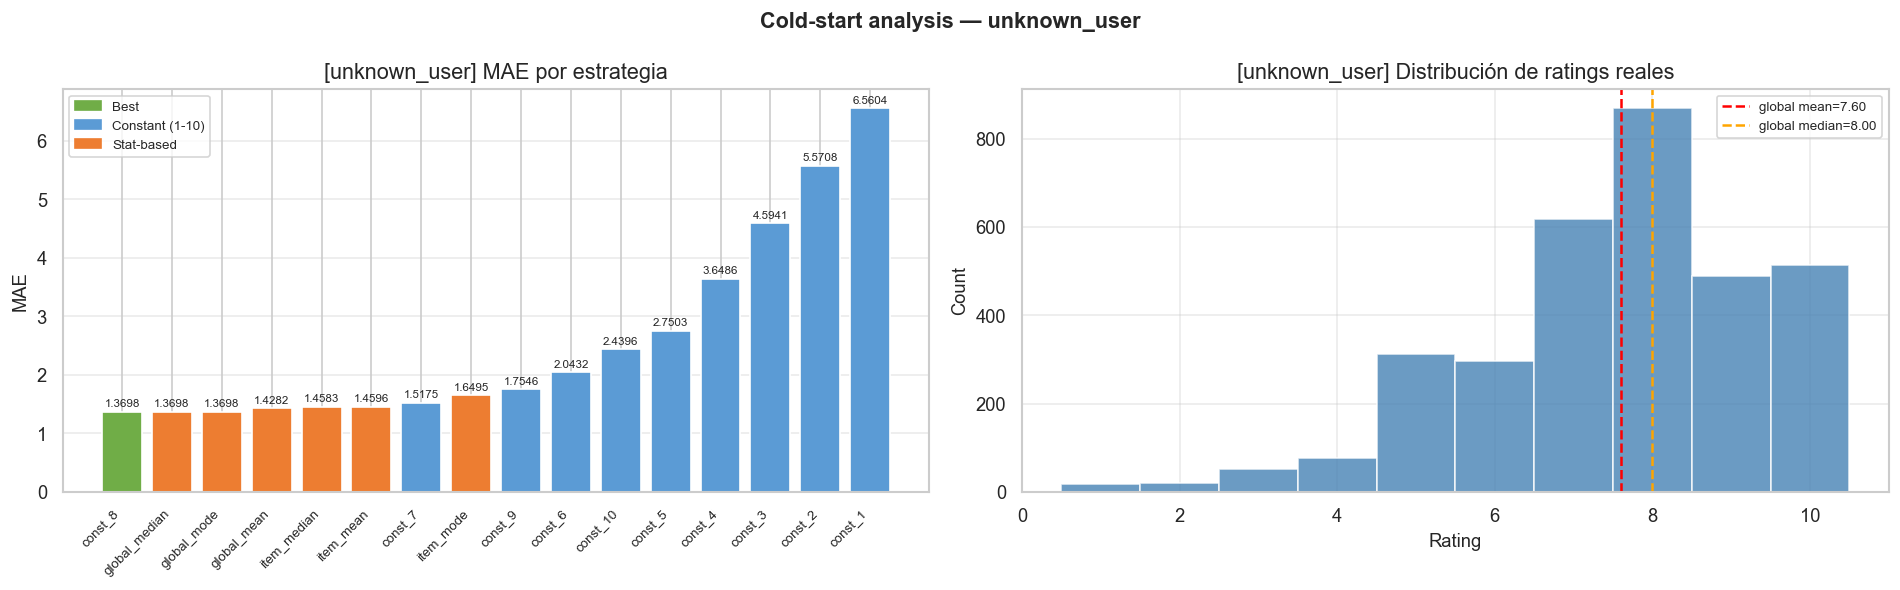


── unknown_item (n=11212) ──────────────────────────────
     strategy      mae
  user_median 1.209329
    user_mean 1.248337
    user_mode 1.323403
      const_8 1.530503
global_median 1.530503
  global_mode 1.530503
  global_mean 1.560968
      const_7 1.607563
      const_9 1.890474
      const_6 2.037103
     const_10 2.528541
      const_5 2.648056
      const_4 3.553157
      const_3 4.502854
      const_2 5.480557
      const_1 6.471459
  → Mejor estrategia: user_median (MAE=1.2093)


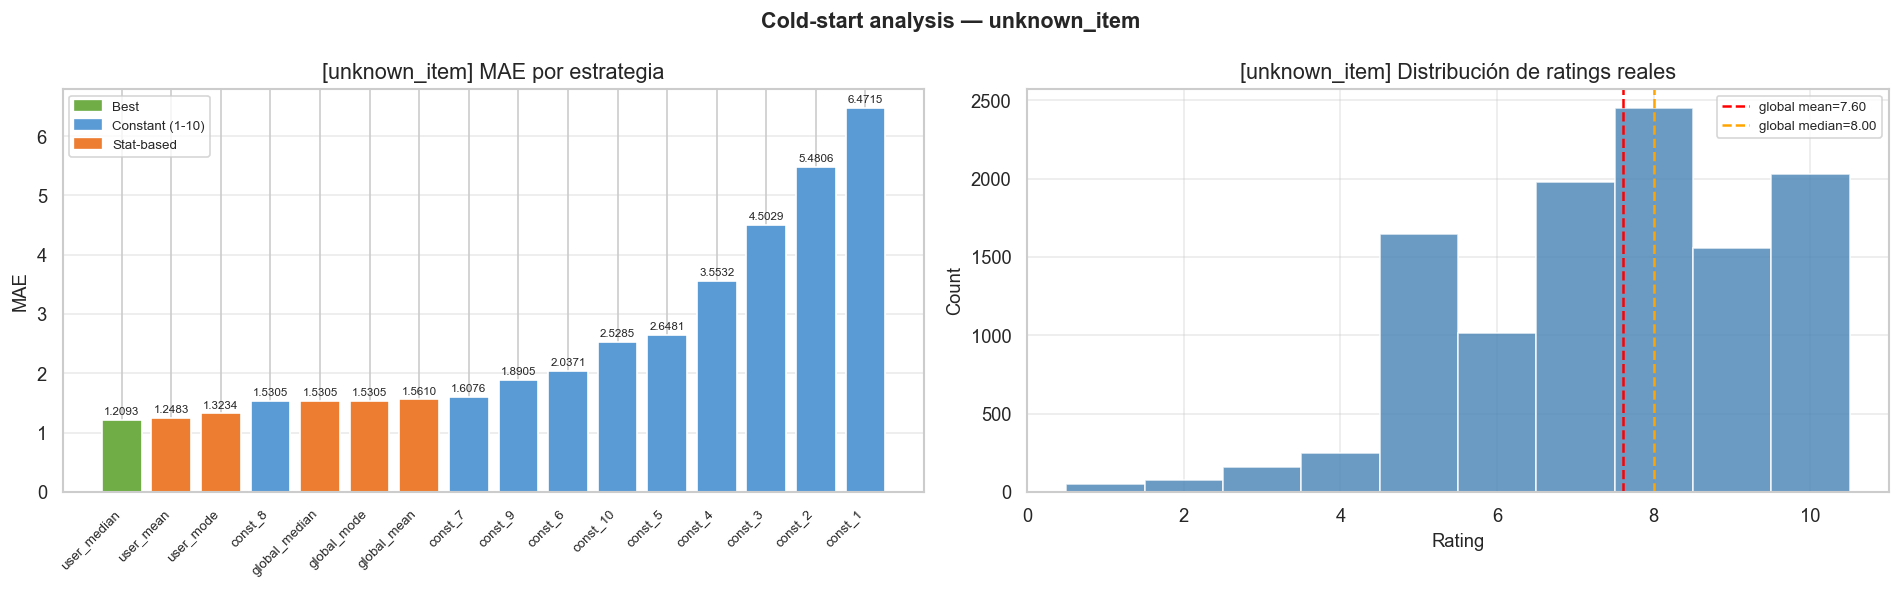


── both_unknown (n=1317) ──────────────────────────────
     strategy      mae
      const_7 1.589977
  global_mean 1.597782
      const_8 1.602885
global_median 1.602885
  global_mode 1.602885
      const_6 1.971906
      const_9 2.053151
      const_5 2.566439
     const_10 2.723614
      const_4 3.423690
      const_3 4.341686
      const_2 5.294609
      const_1 6.276386
  → Mejor estrategia: const_7 (MAE=1.5900)


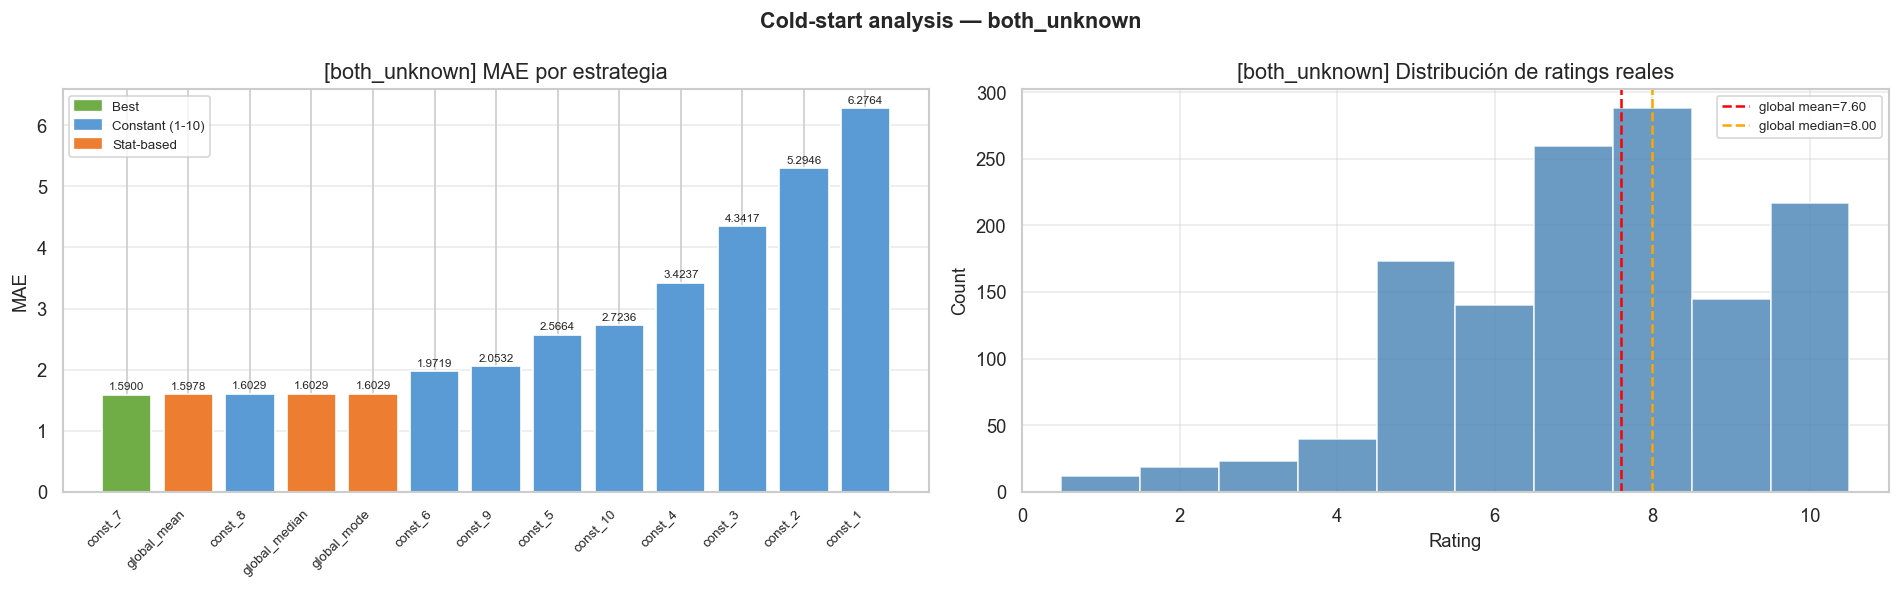

In [15]:
sparse_matrix, user_map, item_map = create_sparse_matrix(x_train, y_train)
best_cs, user_stats, item_stats, global_mean_cs = analyze_coldstart(
    x_train, y_train, x_val, y_val, user_map, item_map
)


Mejores estrategias cold-start seleccionadas:
  unknown_user → const_8
  unknown_item → user_median
  both_unknown → const_7


Evaluating: 100%|██████████| 39036/39036 [01:08<00:00, 569.51it/s]


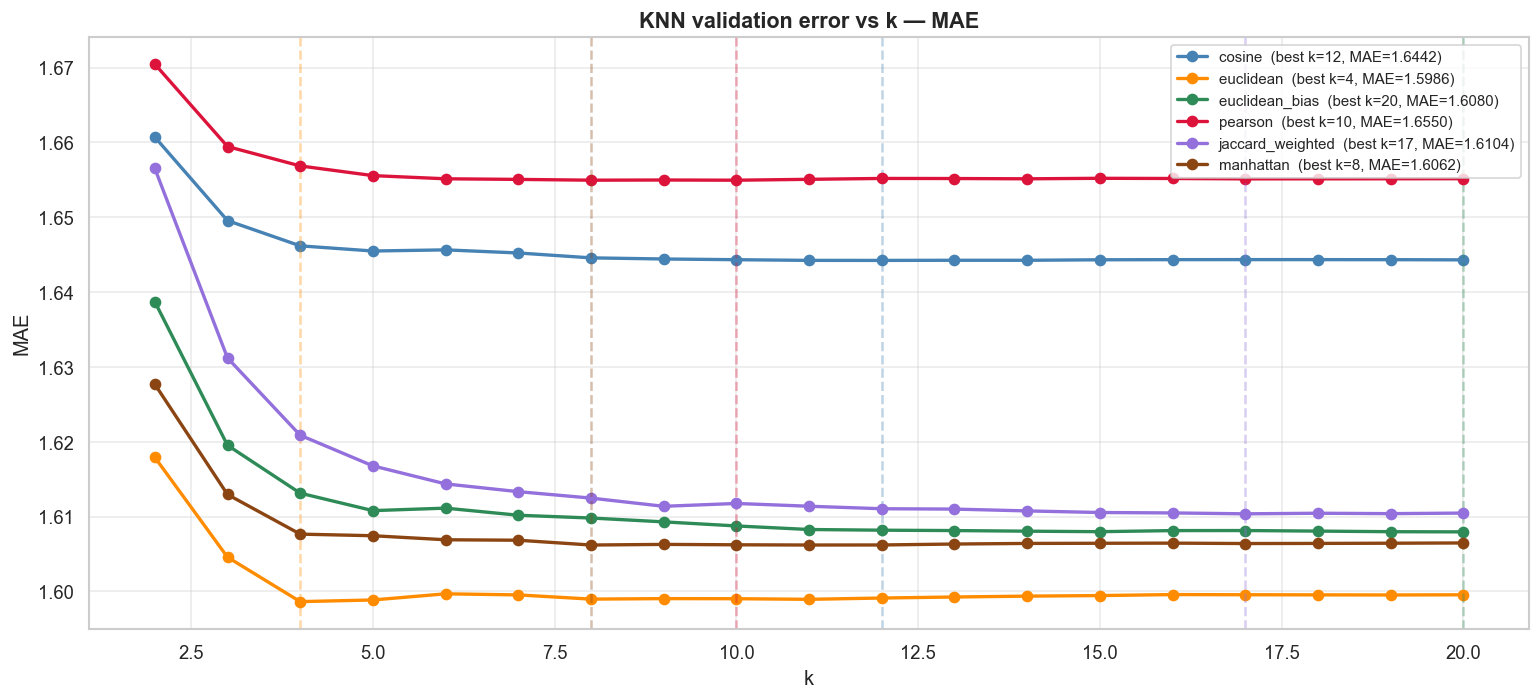


Mejor configuración KNN: metric='euclidean', k=4


Predicting: 100%|██████████| 43320/43320 [00:49<00:00, 869.02it/s] 


In [16]:
# Mejores estrategias
best_cs_unknown_user = best_cs.get('unknown_user', {}).get('strategy', 'global_mean')
best_cs_unknown_item = best_cs.get('unknown_item', {}).get('strategy', 'global_mean')
best_cs_both         = best_cs.get('both_unknown', {}).get('strategy', 'global_mean')

print("\nMejores estrategias cold-start seleccionadas:")
print(f"  unknown_user → {best_cs_unknown_user}")
print(f"  unknown_item → {best_cs_unknown_item}")
print(f"  both_unknown → {best_cs_both}")

user_means, item_means, global_mean = compute_stats(sparse_matrix)

results = evaluate_knn(
    x_val, y_val, sparse_matrix, user_map, item_map,
    k_max=20,
    metrics=['cosine', 'euclidean', 'euclidean_bias',
             'pearson', 'jaccard_weighted', 'manhattan'],
    error_metric='mae',
    cold_start={}
)

best_ks = plot_knn_error(results, error_metric='mae')
best_metric = min(best_ks, key=lambda m: np.nanmin(results['knn'][m][1]))
best_k      = best_ks[best_metric]
print(f"\nMejor configuración KNN: metric='{best_metric}', k={best_k}")

predictions = predict(
    df_test, sparse_matrix, user_map, item_map,
    user_means, item_means, global_mean,
    metric=best_metric,
    k=best_k,
    cold_start_unknown_user=best_cs_unknown_user,
    cold_start_unknown_item=best_cs_unknown_item,
    cold_start_both=best_cs_both,
)

predictions.to_csv('submission_knn.csv', index=False)

Como vemos en los resultados cuando no tenemos ni el usuario ni el ítem el mejor resultado lo obtenemos dando un rating de 7. Cuando solo tenemos el usuario, lo mejor es recomendar la mediana de recomendaciones de ese usuario en particular y cuando solo tenemos el ítem, tenemos que devolver el rating 8 nos da los mejores resultados.

Por otro lado, vemos como Jaccard obtiene los mejores resultados.

# NMF and BNMF

In [17]:
from bnmf import BNMF
from nmf import NMF

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.9477    1.3629     1.8330     0.9274    1.3452     1.7875        ✔ best
     2     0.8789    1.2843     1.7489     0.8857    1.2972     1.7309        ✔ best
     3     0.8339    1.2325     1.6934     0.8635    1.2719     1.7007        ✔ best
     4     0.7989    1.1930     1.6489     0.8491    1.2567     1.6793        ✔ best
     5     0.7703    1.1606     1.6132     0.8388    1.2454     1.6651        ✔ best
     6     0.7458    1.1323     1.5824     0.8315    1.2374     1.6547        ✔ best
     7     0.7245    1.1080     1.5550     0.8261    1.2315     1.6463        ✔ best
     8     0.7055    1.0856     1.5313     0.8218    1.2268     1.6401        ✔ best
     9     0.6882    1.0657     1.5090     0.8182    1.2230     1.6345        ✔ best
    10     0.6726    1.0473     1.4890     0.8158    1.2205     

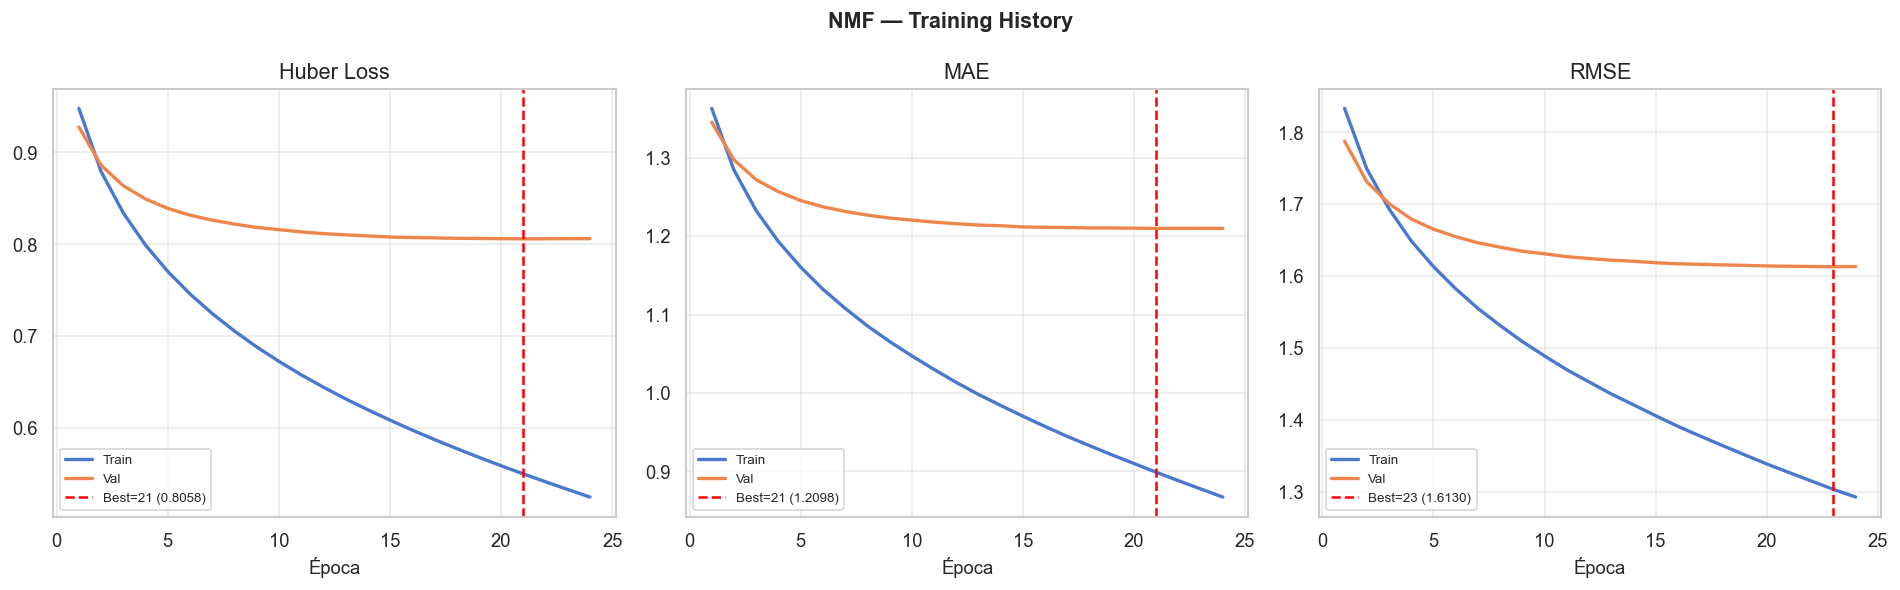

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE     SpU     SpV        Status
────────────────────────────────────────────────────────────────────────────────────────────────────
     1     0.9390    1.3522     1.8227     0.9302    1.3474     1.7892   2.44%   1.33%        ✔ best
     2     0.8626    1.2650     1.7303     0.8885    1.3000     1.7327   4.10%   2.34%        ✔ best
     3     0.8114    1.2062     1.6680     0.8663    1.2751     1.7026   5.50%   3.24%        ✔ best
     4     0.7715    1.1608     1.6181     0.8519    1.2599     1.6817   6.71%   4.04%        ✔ best
     5     0.7385    1.1227     1.5774     0.8416    1.2485     1.6675   7.81%   4.79%        ✔ best
     6     0.7101    1.0896     1.5421     0.8343    1.2407     1.6573   8.82%   5.50%        ✔ best
     7     0.6851    1.0605     1.5104     0.8287    1.2348     1.6488   9.70%   6.15%        ✔ best
     8     0.6625    1.0335     1.4824     0.8244    1.2301     1.6425  10.51%   6.77%     

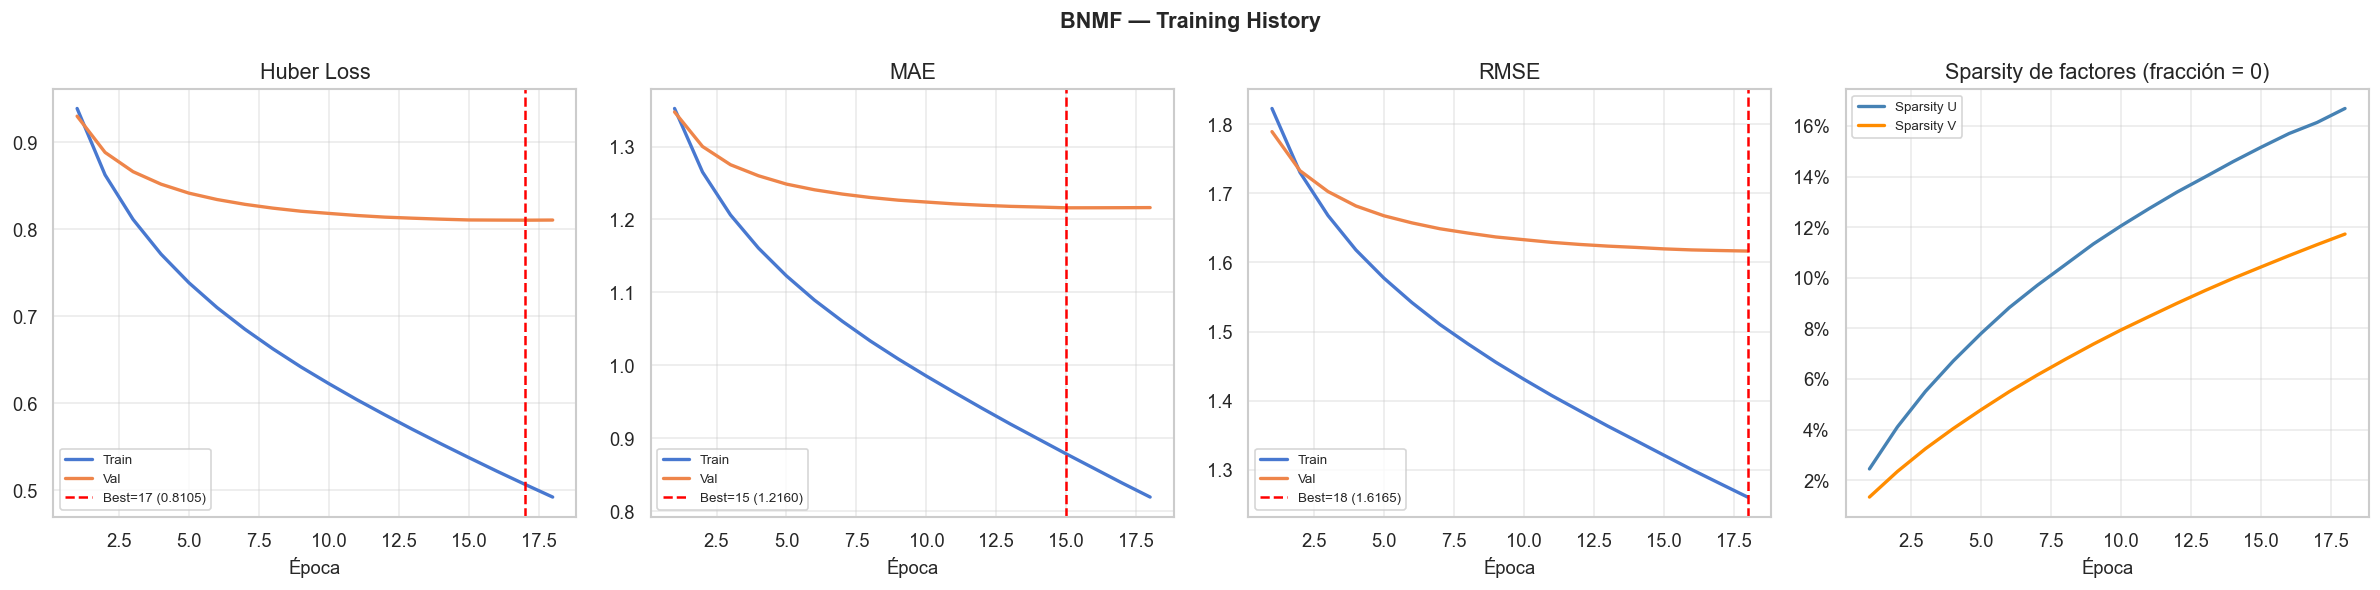

In [18]:
# Parámetros base compartidos
base_params = dict(
    n_factors=200, lambda_bu=0.001, lambda_bi=0.001,
    lr=0.016, n_epochs=100, batch_size=256,
    optimizer='sgd', huber_delta=1.0,
    use_biases=True, log_every=1
)

nmf = NMF(**base_params, lambda_U=0.1, lambda_V=0.1)
nmf.fit(x_train, y_train, x_val, y_val, user_map, item_map, patience=3)
nmf.plot_loss()

bnmf = BNMF(**base_params, lambda_U=0.01, lambda_V=0.01)
bnmf.fit(x_train, y_train, x_val, y_val, user_map, item_map, patience=3)
bnmf.plot_loss()

# PMF y GridSearch de sus hiperparámetros

In [64]:
from pmf import PMF


In [74]:
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42, stratify=df["rating"])

In [79]:
import importlib
import pmf
importlib.reload(pmf)
from pmf import PMF

configs = [
    {'n_factors': f, 'lr': lr, 'reg': reg, 'reg_bias': rb}
    for f   in [200, 300, 400]          # sigue subiendo desde 200
    for lr  in [0.01, 0.015, 0.02]      # sigue subiendo desde 0.01
    for reg in [0.02, 0.03, 0.04]       # sigue subiendo desde 0.02
    for rb  in [0.0005, 0.001, 0.002]   # explora abajo y arriba de 0.001
]

best_mae, best_cfg, best_pmf = float('inf'), None, None
for cfg in configs:
    m = PMF(n_factors=cfg['n_factors'], n_epochs=100,
            lr=cfg['lr'], reg=cfg['reg'],
            reg_bias=cfg['reg_bias'], patience=5)
    m.fit(train_df, val_df)
    val_mae = min(m.val_mae)
    print(f"f={cfg['n_factors']:>3} lr={cfg['lr']} reg={cfg['reg']} rb={cfg['reg_bias']} → {val_mae:.4f}")
    if val_mae < best_mae:
        best_mae = val_mae
        best_cfg = cfg
        best_pmf = m

print(f'\nMejor: {best_cfg} → {best_mae:.4f}')

  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0876 | val: 1.2553


KeyboardInterrupt: 